In [1]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\cjmwo\meituan
['.ipynb_checkpoints', 'testA.csv', 'train .csv', 'Untitled.ipynb', 'Untitled1.ipynb']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
data_train = pd.read_csv('C:/Users/cjmwo/meituan/train .csv')

In [4]:
data_test = pd.read_csv('C:/Users/cjmwo/meituan/testA.csv')

In [5]:
data_train.head(10)

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,0,35000.0,5,19.52,917.97,E,E2,320.0,2 years,2,...,9.0,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0
1,1,18000.0,5,18.49,461.90,D,D2,219843.0,5 years,0,...,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN
2,2,12000.0,5,16.99,298.17,D,D3,31698.0,8 years,0,...,0.0,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0
3,3,11000.0,3,7.26,340.96,A,A4,46854.0,10+ years,1,...,16.0,4.0,7.0,21.0,6.0,9.0,0.0,0.0,0.0,1.0
4,4,3000.0,3,12.99,101.07,C,C2,54.0,NaN,1,...,4.0,9.0,10.0,15.0,7.0,12.0,0.0,0.0,0.0,4.0
5,5,11000.0,3,7.99,344.65,A,A5,51727.0,7 years,0,...,1.0,48.0,2.0,3.0,2.0,19.0,0.0,0.0,0.0,0.0
6,6,2050.0,3,7.69,63.95,A,A4,180083.0,9 years,0,...,11.0,3.0,10.0,18.0,3.0,12.0,0.0,0.0,0.0,3.0
7,7,11500.0,3,14.98,398.54,C,C3,214017.0,1 year,1,...,16.0,10.0,5.0,21.0,4.0,8.0,0.0,0.0,0.0,2.0
8,8,12000.0,3,12.99,404.27,C,C2,188.0,5 years,2,...,7.0,2.0,13.0,17.0,11.0,15.0,NaN,0.0,0.0,6.0
9,9,6500.0,3,10.99,212.78,B,B4,54.0,NaN,1,...,21.0,24.0,6.0,39.0,5.0,7.0,0.0,0.0,0.0,8.0


In [6]:
data_test.shape

(200000, 46)

In [7]:
data_train.shape

(532671, 47)

In [8]:
data_train.columns

Index(['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'grade',
       'subGrade', 'employmentTitle', 'employmentLength', 'homeOwnership',
       'annualIncome', 'verificationStatus', 'issueDate', 'isDefault',
       'purpose', 'postCode', 'regionCode', 'dti', 'delinquency_2years',
       'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec',
       'pubRecBankruptcies', 'revolBal', 'revolUtil', 'totalAcc',
       'initialListStatus', 'applicationType', 'earliesCreditLine', 'title',
       'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8',
       'n9', 'n10', 'n11', 'n12', 'n13', 'n14'],
      dtype='object')

In [9]:
data_test.columns

Index(['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'grade',
       'subGrade', 'employmentTitle', 'employmentLength', 'homeOwnership',
       'annualIncome', 'verificationStatus', 'issueDate', 'purpose',
       'postCode', 'regionCode', 'dti', 'delinquency_2years', 'ficoRangeLow',
       'ficoRangeHigh', 'openAcc', 'pubRec', 'pubRecBankruptcies', 'revolBal',
       'revolUtil', 'totalAcc', 'initialListStatus', 'applicationType',
       'earliesCreditLine', 'title', 'policyCode', 'n0', 'n1', 'n2', 'n3',
       'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n11', 'n12', 'n13', 'n14'],
      dtype='object')

In [10]:
data_train.describe()

,id,loanAmnt,term,interestRate,installment,employmentTitle,homeOwnership,annualIncome,verificationStatus,isDefault,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
count,532671.000000,532671.000000,532671.000000,532671.000000,532671.000000,532670.000000,532671.000000,5.326710e+05,532671.000000,532670.000000,...,505721.000000,505721.000000,505721.000000,505721.000000,505721.000000,510442.000000,486134.000000,505721.000000,505721.000000,505721.000000
mean,266335.000000,14413.209232,3.482737,13.233641,437.830276,72064.757189,0.614238,7.607905e+04,1.008959,0.199501,...,8.109798,8.583861,8.287394,14.631289,5.594173,11.648994,0.000817,0.003377,0.089502,2.178743
std,153769.016957,8705.182159,0.855827,4.766336,261.117772,106575.147011,0.676215,6.914129e+04,0.782541,0.399625,...,4.798611,7.402932,4.565344,8.126505,3.214583,5.485318,0.030040,0.061940,0.514151,1.846355
min,0.000000,500.000000,3.000000,5.310000,15.690000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,133167.500000,8000.000000,3.000000,9.750000,248.520000,427.000000,0.000000,4.550000e+04,0.000000,0.000000,...,5.000000,4.000000,5.000000,9.000000,3.000000,8.000000,0.000000,0.000000,0.000000,1.000000
50%,266335.000000,12000.000000,3.000000,12.740000,375.120000,7820.000000,1.000000,6.500000e+04,1.000000,0.000000,...,7.000000,7.000000,7.000000,13.000000,5.000000,11.000000,0.000000,0.000000,0.000000,2.000000
75%,399502.500000,20000.000000,3.000000,15.990000,580.220000,117932.250000,1.000000,9.000000e+04,2.000000,0.000000,...,11.000000,11.000000,10.000000,19.000000,7.000000,14.000000,0.000000,0.000000,0.000000,3.000000
max,532670.000000,40000.000000,5.000000,30.990000,1715.420000,378350.000000,5.000000,1.099920e+07,2.000000,1.000000,...,70.000000,132.000000,79.000000,128.000000,45.000000,82.000000,4.000000,4.000000,39.000000,28.000000


In [11]:
pd.concat([data_train.head(3),data_train.tail(3)])

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,0,35000.0,5,19.52,917.97,E,E2,320.0,2 years,2,...,9.0,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0
1,1,18000.0,5,18.49,461.90,D,D2,219843.0,5 years,0,...,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN
2,2,12000.0,5,16.99,298.17,D,D3,31698.0,8 years,0,...,0.0,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0
532668,532668,21000.0,5,16.02,510.91,C,C5,123290.0,9 years,1,...,4.0,16.0,7.0,8.0,4.0,17.0,0.0,0.0,0.0,4.0
532669,532669,9000.0,3,9.16,286.87,B,B2,1375.0,10+ years,1,...,10.0,13.0,13.0,19.0,12.0,16.0,0.0,0.0,0.0,4.0
532670,532670,3500.0,3,12.88,117.73,C,C2,666.0,10+ years,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
data_train.isnull().any().sum()

36

In [13]:
data_train.isnull()

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n5,n6,n7,n8,n9,n10,n11,n12,n13,n14
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,False,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532666,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
532667,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
532668,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
532669,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
print(f'There are {data_train.isnull().any().sum()} columns in train dataset with missing values.')

There are 36 columns in train dataset with missing values.


In [15]:
have_null_fea_dict = (data_train.isnull().sum()/len(data_train)).to_dict()
fea_null_moreThanHalf = {}
for key,value in have_null_fea_dict.items():
    if value > 0.5:
        fea_null_moreThanHalf[key] = value

In [16]:
fea_null_moreThanHalf

{}

<Axes: >

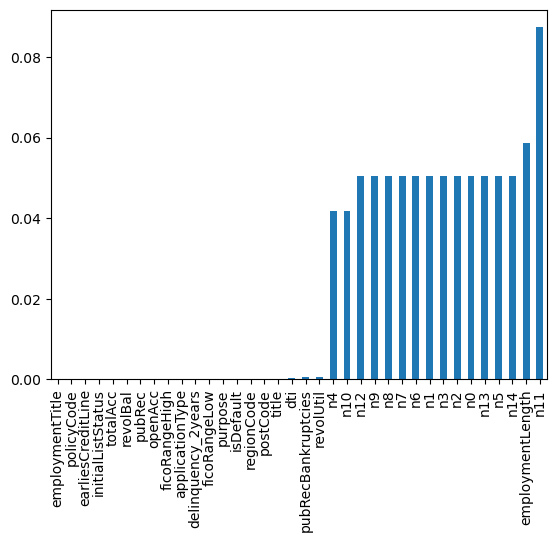

In [17]:
missing = data_train.isnull().sum()/len(data_train)
missing = missing[missing > 0]
missing.sort_values(inplace=True)
missing.plot.bar()

In [18]:
one_value_fea = [col for col in data_train.columns if data_train[col].nunique() <= 1]

In [19]:
one_value_fea_test = [col for col in data_test.columns if data_test[col].nunique() <= 1]

In [20]:
one_value_fea

['policyCode']

In [21]:
one_value_fea_test

['policyCode']

筛选出数据集中取值唯一或全为空的无用特征列，方便后续直接删除

In [23]:
numerical_fea = list(data_train.select_dtypes(exclude=['object']).columns)
category_fea = list(filter(lambda x: x not in numerical_fea,list(data_train.columns)))

In [24]:
numerical_fea

['id',
 'loanAmnt',
 'term',
 'interestRate',
 'installment',
 'employmentTitle',
 'homeOwnership',
 'annualIncome',
 'verificationStatus',
 'isDefault',
 'purpose',
 'postCode',
 'regionCode',
 'dti',
 'delinquency_2years',
 'ficoRangeLow',
 'ficoRangeHigh',
 'openAcc',
 'pubRec',
 'pubRecBankruptcies',
 'revolBal',
 'revolUtil',
 'totalAcc',
 'initialListStatus',
 'applicationType',
 'title',
 'policyCode',
 'n0',
 'n1',
 'n2',
 'n3',
 'n4',
 'n5',
 'n6',
 'n7',
 'n8',
 'n9',
 'n10',
 'n11',
 'n12',
 'n13',
 'n14']

In [25]:
category_fea

['grade', 'subGrade', 'employmentLength', 'issueDate', 'earliesCreditLine']

In [26]:
data_train.grade

0         E
1         D
2         D
3         A
4         C
         ..
532666    C
532667    C
532668    C
532669    B
532670    C
Name: grade, Length: 532671, dtype: object

自动把数据集的所有列分成【数值型特征】和【分类型特征】两类，方便后续分别处理

In [28]:
#过滤数值型类别特征
def get_numerical_serial_fea(data,feas):
    numerical_serial_fea = []
    numerical_noserial_fea = []
    for fea in feas:
        temp = data[fea].nunique()
        if temp <= 10:
            numerical_noserial_fea.append(fea)
            continue
        numerical_serial_fea.append(fea)
    return numerical_serial_fea,numerical_noserial_fea
numerical_serial_fea,numerical_noserial_fea = get_numerical_serial_fea(data_train,numerical_fea)

In [29]:
numerical_serial_fea

['id',
 'loanAmnt',
 'interestRate',
 'installment',
 'employmentTitle',
 'annualIncome',
 'purpose',
 'postCode',
 'regionCode',
 'dti',
 'delinquency_2years',
 'ficoRangeLow',
 'ficoRangeHigh',
 'openAcc',
 'pubRec',
 'revolBal',
 'revolUtil',
 'totalAcc',
 'title',
 'n0',
 'n1',
 'n2',
 'n3',
 'n4',
 'n5',
 'n6',
 'n7',
 'n8',
 'n9',
 'n10',
 'n13',
 'n14']

In [30]:
numerical_noserial_fea

['term',
 'homeOwnership',
 'verificationStatus',
 'isDefault',
 'pubRecBankruptcies',
 'initialListStatus',
 'applicationType',
 'policyCode',
 'n11',
 'n12']

def get_numerical_serial_fea(data,feas):
    # 存放 连续数值特征（比如价格、年龄）
    numerical_serial_fea = []
    # 存放 离散数值特征（比如星级、评分）
    numerical_noserial_fea = []

    # 遍历所有传入的数值列
    for fea in feas:
        # 计算这一列有多少种不同的值
        temp = data[fea].nunique()
        
        # 如果不同值 ≤ 10种 → 归为离散数值
        if temp <= 10:
            numerical_noserial_fea.append(fea)
            continue
        
        # 否则 → 归为连续数值
        numerical_serial_fea.append(fea)
        
    return numerical_serial_fea,numerical_noserial_fea

# 调用函数，拆分数值特征
numerical_serial_fea,numerical_noserial_fea = get_numerical_serial_fea(dat
数一下数值列有多少种不同的值，≤10 的算离散特征，超过 10 的算连续特征，并自动分开a_train,numerical_fea)

In [32]:
data_train['term'].value_counts()#离散型变量

term
3    404101
5    128570
Name: count, dtype: int64

In [33]:
data_train['homeOwnership'].value_counts()#离散型变量
data_train['verificationStatus'].value_counts()#离散型变量
data_train['initialListStatus'].value_counts()#离散型变量
data_train['applicationType'].value_counts()
data_train['n11'].value_counts()
data_train['n12'].value_counts()
#离散型变量，相差悬殊，用不用再分析

n12
0.0    504116
1.0      1516
2.0        77
3.0        10
4.0         2
Name: count, dtype: int64

In [34]:
# 把你要一起看的列放进列表
cols = [
    'homeOwnership',
    'verificationStatus',
    'initialListStatus',
    'applicationType',
    'n11',
    'n12'
]

# 循环批量输出 value_counts
for col in cols:
    print(f'===== {col} =====')
    print(data_train[col].value_counts())
    print('\n')

===== homeOwnership =====
homeOwnership
0    263626
1    211246
2     57593
3       125
5        56
4        25
Name: count, dtype: int64


===== verificationStatus =====
verificationStatus
1    206437
2    165503
0    160731
Name: count, dtype: int64


===== initialListStatus =====
initialListStatus
0.0    310835
1.0    221835
Name: count, dtype: int64


===== applicationType =====
applicationType
0.0    522395
1.0     10275
Name: count, dtype: int64


===== n11 =====
n11
0.0    485754
1.0       366
2.0        12
4.0         1
3.0         1
Name: count, dtype: int64


===== n12 =====
n12
0.0    504116
1.0      1516
2.0        77
3.0        10
4.0         2
Name: count, dtype: int64




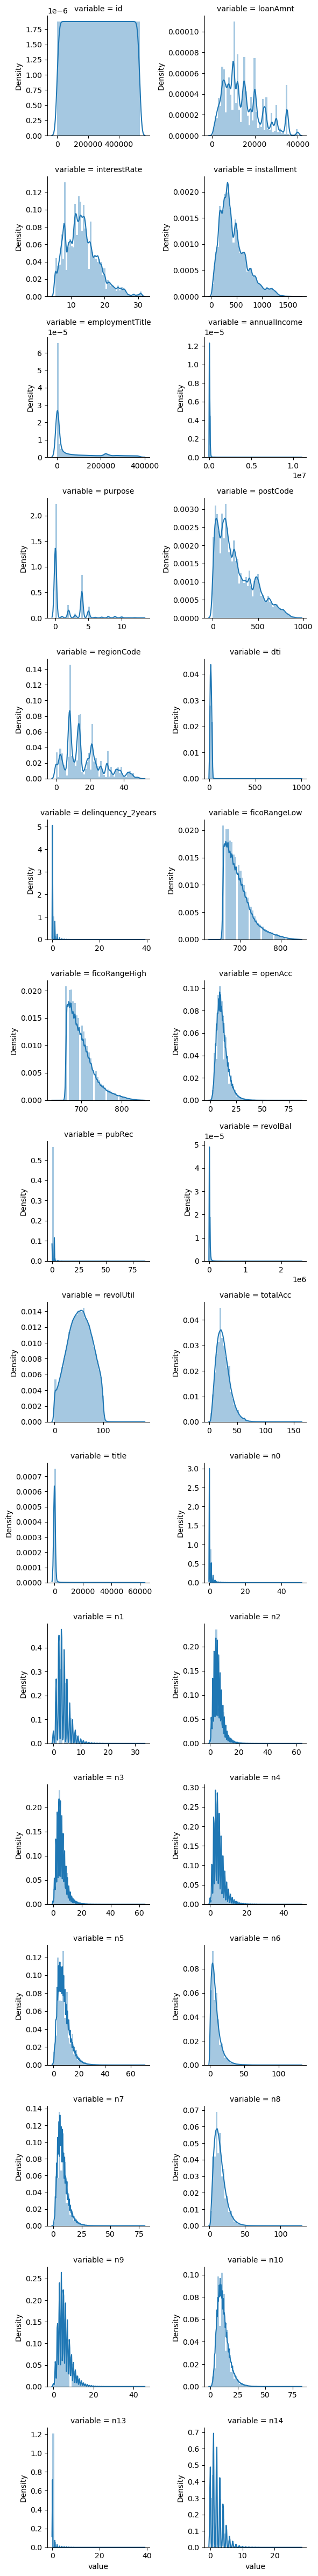

In [35]:
f = pd.melt(data_train, value_vars=numerical_serial_fea)
g = sns.FacetGrid(f, col="variable",  col_wrap=2, sharex=False, sharey=False)
g = g.map(sns.distplot, "value")

Text(0, 0.5, 'Probability')

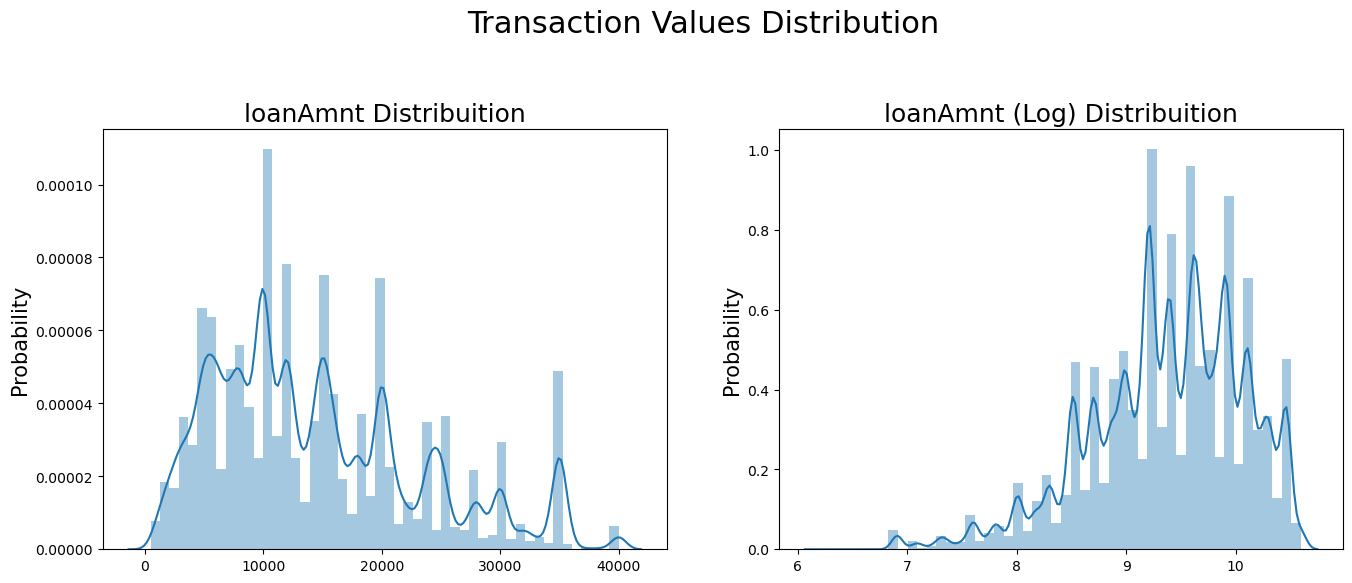

In [36]:
#Ploting Transaction Amount Values Distribution
plt.figure(figsize=(16,12))
plt.suptitle('Transaction Values Distribution', fontsize=22)
plt.subplot(221)
sub_plot_1 = sns.distplot(data_train['loanAmnt'])
sub_plot_1.set_title("loanAmnt Distribuition", fontsize=18)
sub_plot_1.set_xlabel("")
sub_plot_1.set_ylabel("Probability", fontsize=15)

plt.subplot(222)
sub_plot_2 = sns.distplot(np.log(data_train['loanAmnt']))
sub_plot_2.set_title("loanAmnt (Log) Distribuition", fontsize=18)
sub_plot_2.set_xlabel("")
sub_plot_2.set_ylabel("Probability", fontsize=15)

In [37]:
from scipy.stats import kstest, norm

print("="*60)
print("        连续特征 正态分布检验结果")
print("="*60)

normal_feas = []
non_normal_feas = []

for fea in numerical_serial_fea:
    # 不抽样，用全部数据，先去掉空值
    data = data_train[fea].dropna()
    
    # KS 检验（大数据专用）
    stat, p = kstest(data, norm.cdf)
    
    # 规则：p < 0.05 → 非正态
    if p < 0.05:
        res = " 非正态"
        non_normal_feas.append(fea)
    else:
        res = "正态"
        normal_feas.append(fea)
    
    print(f"{fea:<22} p={p:.8f}   {res}")

print("="*60)
print(f"符合正态分布：{normal_feas}")
print(f"不符合正态分布：{non_normal_feas}")

        连续特征 正态分布检验结果
id                     p=0.00000000    非正态
loanAmnt               p=0.00000000    非正态
interestRate           p=0.00000000    非正态
installment            p=0.00000000    非正态
employmentTitle        p=0.00000000    非正态
annualIncome           p=0.00000000    非正态
purpose                p=0.00000000    非正态
postCode               p=0.00000000    非正态
regionCode             p=0.00000000    非正态
dti                    p=0.00000000    非正态
delinquency_2years     p=0.00000000    非正态
ficoRangeLow           p=0.00000000    非正态
ficoRangeHigh          p=0.00000000    非正态
openAcc                p=0.00000000    非正态
pubRec                 p=0.00000000    非正态
revolBal               p=0.00000000    非正态
revolUtil              p=0.00000000    非正态
totalAcc               p=0.00000000    非正态
title                  p=0.00000000    非正态
n0                     p=0.00000000    非正态
n1                     p=0.00000000    非正态
n2                     p=0.00000000    非正态
n3                     p=0.00000

In [38]:
data_train['isDefault'].value_counts()

isDefault
0.0    426402
1.0    106268
Name: count, dtype: int64

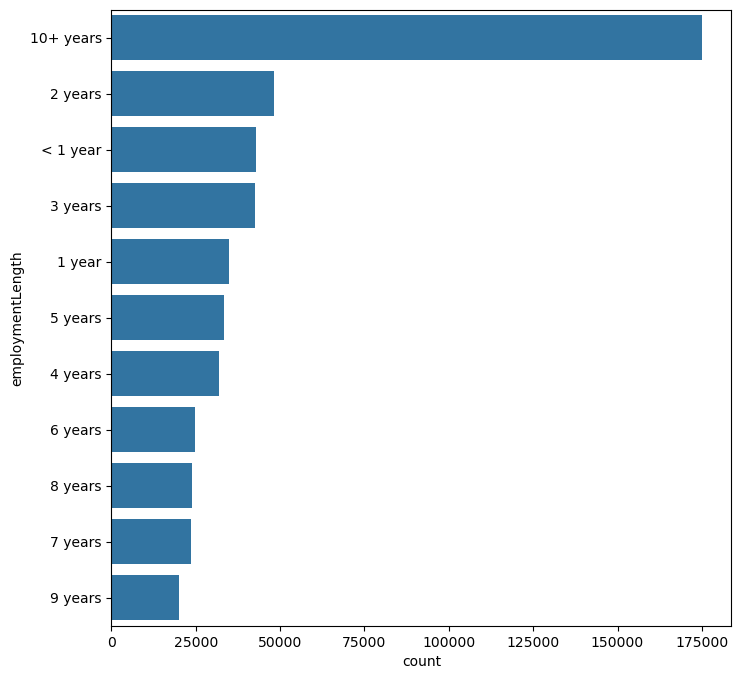

In [39]:
plt.figure(figsize=(8,8))
count = data_train['employmentLength'].value_counts(dropna=False)[:20]
sns.barplot(x=count, y=count.index)
plt.show()

In [40]:
train_loan_fr = data_train.loc[data_train['isDefault'] == 1]
train_loan_nofr = data_train.loc[data_train['isDefault'] == 0]

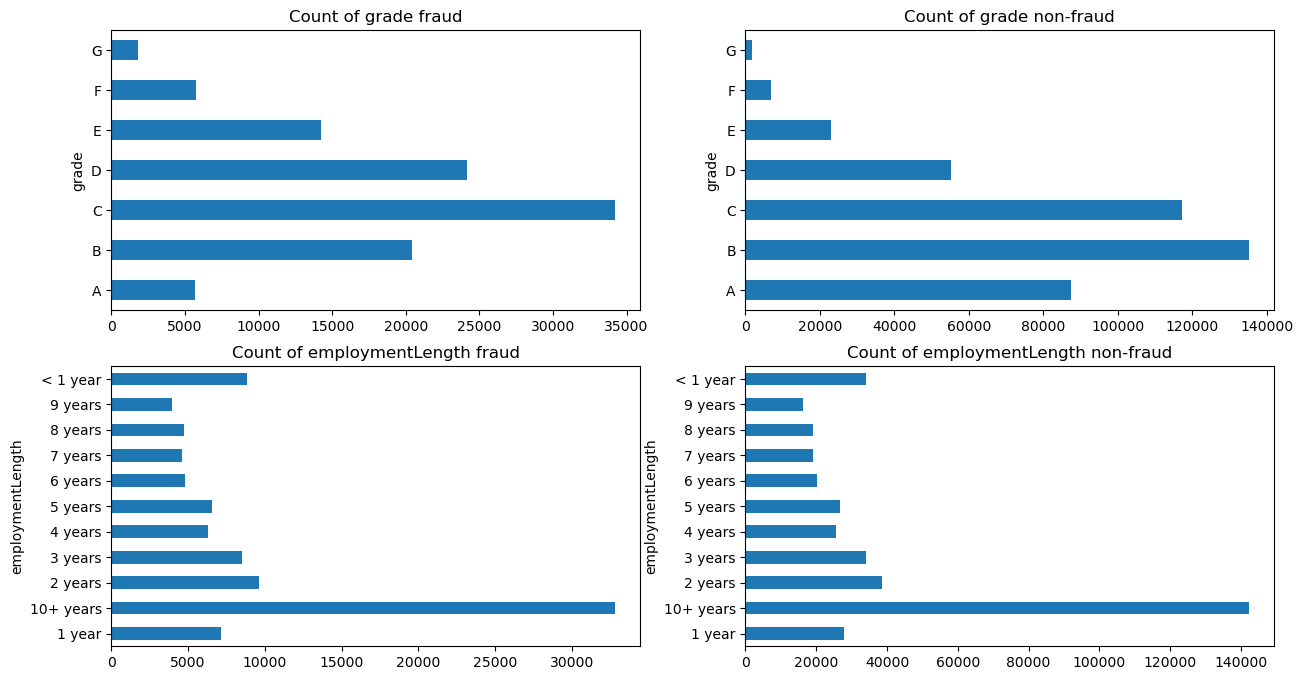

In [41]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 8))
train_loan_fr.groupby('grade')['grade'].count().plot(kind='barh', ax=ax1, title='Count of grade fraud')
train_loan_nofr.groupby('grade')['grade'].count().plot(kind='barh', ax=ax2, title='Count of grade non-fraud')
train_loan_fr.groupby('employmentLength')['employmentLength'].count().plot(kind='barh', ax=ax3, title='Count of employmentLength fraud')
train_loan_nofr.groupby('employmentLength')['employmentLength'].count().plot(kind='barh', ax=ax4, title='Count of employmentLength non-fraud')
plt.show()

<Axes: title={'center': 'Log Loan Amt - Not Fraud'}, ylabel='Frequency'>

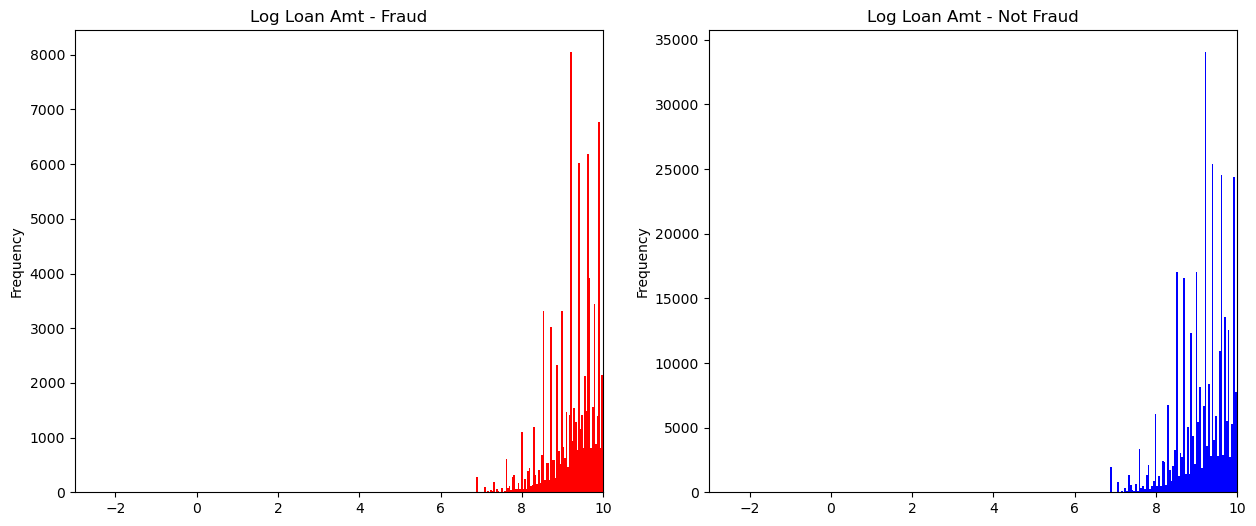

In [42]:
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 6))
data_train.loc[data_train['isDefault'] == 1] \
    ['loanAmnt'].apply(np.log) \
    .plot(kind='hist',
          bins=100,
          title='Log Loan Amt - Fraud',
          color='r',
          xlim=(-3, 10),
         ax= ax1)
data_train.loc[data_train['isDefault'] == 0] \
    ['loanAmnt'].apply(np.log) \
    .plot(kind='hist',
          bins=100,
          title='Log Loan Amt - Not Fraud',
          color='b',
          xlim=(-3, 10),
         ax=ax2)

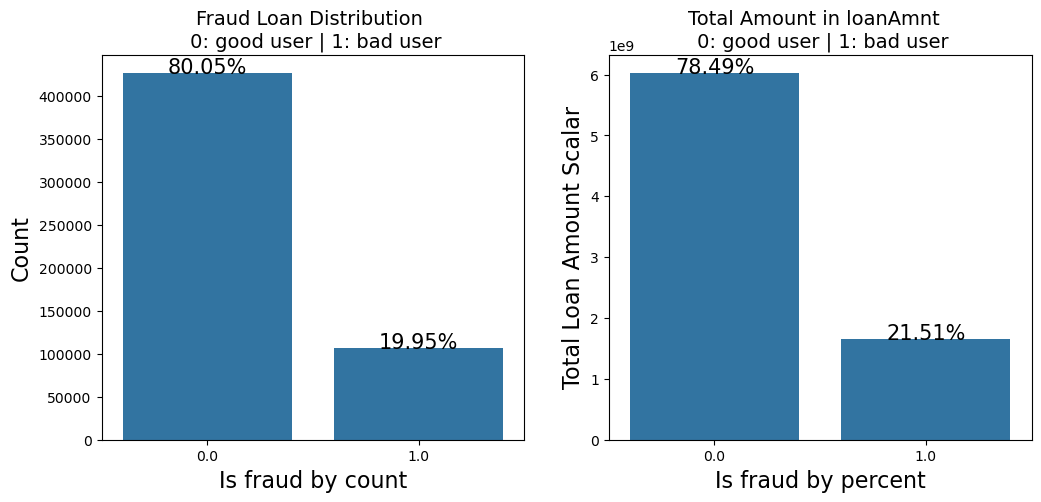

In [43]:
total = len(data_train)
total_amt = data_train.groupby(['isDefault'])['loanAmnt'].sum().sum()
plt.figure(figsize=(12,5))
plt.subplot(121)##1代表行，2代表列，所以一共有2个图，1代表此时绘制第一个图。
plot_tr = sns.countplot(x='isDefault',data=data_train)#data_train‘isDefault’这个特征每种类别的数量**
plot_tr.set_title("Fraud Loan Distribution \n 0: good user | 1: bad user", fontsize=14)
plot_tr.set_xlabel("Is fraud by count", fontsize=16)
plot_tr.set_ylabel('Count', fontsize=16)
for p in plot_tr.patches:
    height = p.get_height()
    plot_tr.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=15) 
    
percent_amt = (data_train.groupby(['isDefault'])['loanAmnt'].sum())
percent_amt = percent_amt.reset_index()
plt.subplot(122)
plot_tr_2 = sns.barplot(x='isDefault', y='loanAmnt',  dodge=True, data=percent_amt)
plot_tr_2.set_title("Total Amount in loanAmnt  \n 0: good user | 1: bad user", fontsize=14)
plot_tr_2.set_xlabel("Is fraud by percent", fontsize=16)
plot_tr_2.set_ylabel('Total Loan Amount Scalar', fontsize=16)
for p in plot_tr_2.patches:
    height = p.get_height()
    plot_tr_2.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total_amt * 100),
            ha="center", fontsize=15)     

In [44]:
import datetime
import pandas as pd

# 关键：加了 errors='coerce' 容错
data_train['issueDate'] = pd.to_datetime(data_train['issueDate'], format='%Y-%m-%d', errors='coerce')

startdate = datetime.datetime.strptime('2007-06-01', '%Y-%m-%d')
data_train['issueDateDT'] = data_train['issueDate'].apply(lambda x: x - startdate).dt.days

In [45]:
data_test['issueDate'] = pd.to_datetime(data_train['issueDate'],format='%Y-%m-%d')
startdate = datetime.datetime.strptime('2007-06-01', '%Y-%m-%d')
data_test['issueDateDT'] = data_test['issueDate'].apply(lambda x: x-startdate).dt.days

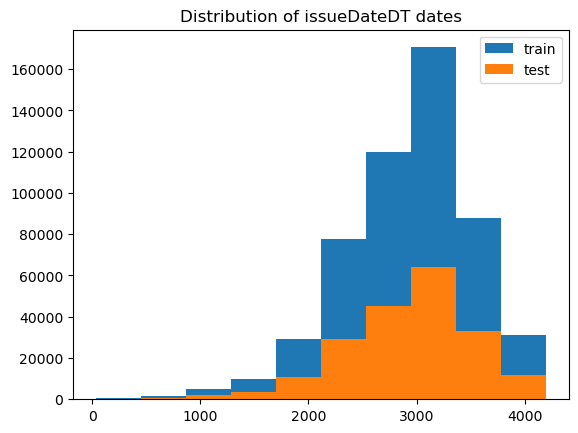

In [46]:
plt.hist(data_train['issueDateDT'], label='train');
plt.hist(data_test['issueDateDT'], label='test');
plt.legend();
plt.title('Distribution of issueDateDT dates');
#train 和 test issueDateDT 日期有重叠 所以使用基于时间的分割进行验证是不明智的

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
warnings.filterwarnings('ignore')

In [48]:
numerical_fea = list(data_train.select_dtypes(exclude=['object']).columns)
category_fea = list(filter(lambda x: x not in numerical_fea,list(data_train.columns)))
label = 'isDefault'
numerical_fea.remove(label)

# 1. 选出所有【数值型】特征的列名（排除文本/object类型）
numerical_fea = list(data_train.select_dtypes(exclude=['object']).columns)

# 2. 选出所有【类别型】特征的列名（不在数值型里的列）
category_fea = list(filter(lambda x: x not in numerical_fea, list(data_train.columns)))

# 3. 指定标签列（目标变量，要预测的列）
label = 'isDefault'

# 4. 把标签列从数值特征中删掉（因为标签不是特征！）
numerical_fea.remove(label)

In [50]:
data_train.isnull().sum()

id                        0
loanAmnt                  0
term                      0
interestRate              0
installment               0
grade                     0
subGrade                  0
employmentTitle           1
employmentLength      31260
homeOwnership             0
annualIncome              0
verificationStatus        0
issueDate                 1
isDefault                 1
purpose                   1
postCode                  2
regionCode                1
dti                     154
delinquency_2years        1
ficoRangeLow              1
ficoRangeHigh             1
openAcc                   1
pubRec                    1
pubRecBankruptcies      265
revolBal                  1
revolUtil               353
totalAcc                  1
initialListStatus         1
applicationType           1
earliesCreditLine         1
title                     2
policyCode                1
n0                    26950
n1                    26950
n2                    26950
n3                  

In [51]:
#按照中位数填充数值型特征
data_train[numerical_fea] = data_train[numerical_fea].fillna(data_train[numerical_fea].median())
data_test[numerical_fea] = data_test[numerical_fea].fillna(data_train[numerical_fea].median())
#按照众数填充类别型特征
data_train[category_fea] = data_train[category_fea].fillna(data_train[category_fea].mode())
data_test[category_fea] = data_test[category_fea].fillna(data_train[category_fea].mode())

In [52]:
data_train[label] = data_train[label].fillna(data_train[label].median())

In [53]:
data_train.isnull().sum()

id                        0
loanAmnt                  0
term                      0
interestRate              0
installment               0
grade                     0
subGrade                  0
employmentTitle           0
employmentLength      31260
homeOwnership             0
annualIncome              0
verificationStatus        0
issueDate                 0
isDefault                 0
purpose                   0
postCode                  0
regionCode                0
dti                       0
delinquency_2years        0
ficoRangeLow              0
ficoRangeHigh             0
openAcc                   0
pubRec                    0
pubRecBankruptcies        0
revolBal                  0
revolUtil                 0
totalAcc                  0
initialListStatus         0
applicationType           0
earliesCreditLine         1
title                     0
policyCode                0
n0                        0
n1                        0
n2                        0
n3                  

In [54]:
data_train['employmentLength'].value_counts(dropna=False).sort_index()

employmentLength
1 year        34934
10+ years    174992
2 years       48189
3 years       42508
4 years       32000
5 years       33309
6 years       24846
7 years       23552
8 years       23931
9 years       20153
< 1 year      42997
NaN           31260
Name: count, dtype: int64

In [55]:
data_train['employmentLength'].value_counts(dropna=False).sort_index()

employmentLength
1 year        34934
10+ years    174992
2 years       48189
3 years       42508
4 years       32000
5 years       33309
6 years       24846
7 years       23552
8 years       23931
9 years       20153
< 1 year      42997
NaN           31260
Name: count, dtype: int64


样本数量：
isDefault
0.0    426403
1.0    106268
Name: count, dtype: int64

样本占比：
isDefault
0.0    0.8005
1.0    0.1995
Name: proportion, dtype: float64


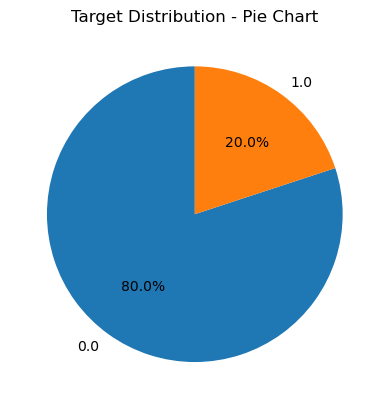

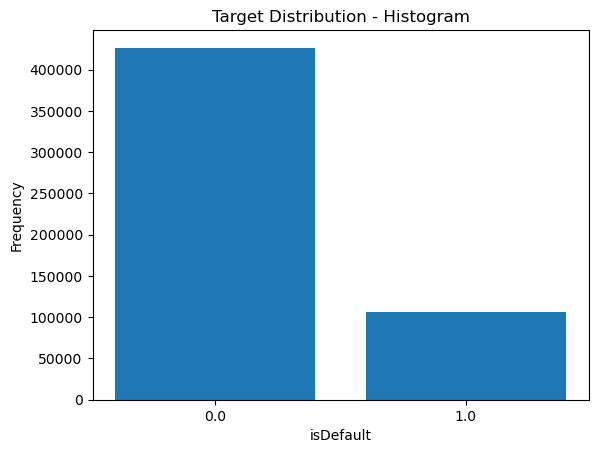

In [56]:
# ======================
# 目标变量
# ======================
target_col = 'isDefault'   # ⚠️ 如果报错，后面有自动识别版本

# ======================
# 分布统计
# ======================
counts = data_train[target_col].value_counts().sort_index()
ratio = data_train[target_col].value_counts(normalize=True).sort_index()

print("\n样本数量：")
print(counts)

print("\n样本占比：")
print(ratio)

# ======================
# 画图
# ======================
import matplotlib.pyplot as plt

# 饼图
plt.figure()
counts.plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Target Distribution - Pie Chart')
plt.ylabel('')
plt.show()

# 柱状图（推荐替代 histogram）
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Target Distribution - Histogram')
plt.xlabel(target_col)
plt.ylabel('Frequency')
plt.show()

目标变量 isDefault 的分布约为 8:2，其中非违约样本占约 80%，违约样本占约 20%。

该数据集存在一定程度的类别不平衡，但未达到严重不平衡水平（如 95:5）。
因此，在建模初期可以直接使用原始数据进行训练，同时在模型优化阶段
可考虑引入重采样方法（如 SMOTE 或下采样）以进一步提升模型对违约样本的识别能力。

In [58]:
category_fea

['grade', 'subGrade', 'employmentLength', 'earliesCreditLine']

In [59]:
def emp_to_num(x):
    if pd.isnull(x):
        return -1
    if x == '< 1 year':
        return 0
    if x == '10+ years':
        return 10
    return int(x.split()[0])

data_train['employmentLength'] = data_train['employmentLength'].apply(emp_to_num)
data_test['employmentLength'] = data_test['employmentLength'].apply(emp_to_num)

In [60]:
data_train['employmentLength'].value_counts(dropna=False).sort_index()

employmentLength
-1      31260
 0      42997
 1      34934
 2      48189
 3      42508
 4      32000
 5      33309
 6      24846
 7      23552
 8      23931
 9      20153
 10    174992
Name: count, dtype: int64

In [61]:
data_train.groupby('employmentLength')['isDefault'].mean()

employmentLength
-1     0.269834
 0     0.205363
 1     0.205244
 2     0.199859
 3     0.199774
 4     0.196813
 5     0.196523
 6     0.192425
 7     0.194548
 8     0.198028
 9     0.196844
 10    0.187420
Name: isDefault, dtype: float64

employmentLength
 10    0.187420
 6     0.192425
 7     0.194548
 5     0.196523
 4     0.196813
 9     0.196844
 8     0.198028
 3     0.199774
 2     0.199859
 1     0.205244
 0     0.205363
-1     0.269834
Name: isDefault, dtype: float64


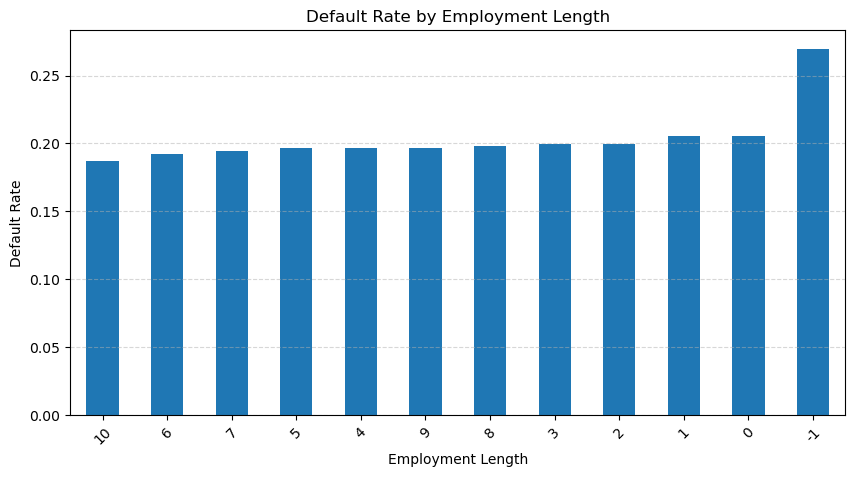

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================
# 1. 确认目标变量
# ======================
target_col = 'isDefault'  # 如果你是 isDefault，改这里

# ======================
# 2. 计算每个工作年限的违约率
# ======================
rate = data_train.groupby('employmentLength')[target_col].mean().sort_values()

print(rate)

# ======================
# 3. 画图（违约率排序图）
# ======================
plt.figure(figsize=(10,5))

rate.plot(kind='bar')

plt.title('Default Rate by Employment Length')
plt.xlabel('Employment Length')
plt.ylabel('Default Rate')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [63]:
data_train['earliesCreditLine'].sample(5)

123330    Jan-2009
262880    Jan-1995
67514     Nov-2005
279119    Oct-1981
390373    Nov-2003
Name: earliesCreditLine, dtype: object

In [64]:
for data in [data_train, data_test]:
    # 1. 如果还是字符串，先转成年份
    data['earliesCreditLine'] = pd.to_datetime(
        data['earliesCreditLine'], errors='coerce'
    ).dt.year

    # 2. 删除缺失值
    data.dropna(subset=['earliesCreditLine'], inplace=True)

    # 3. 转成 int
    data['earliesCreditLine'] = data['earliesCreditLine'].astype(int)

In [65]:
data_train['earliesCreditLine'].dtype

dtype('int32')

In [66]:
data_train['earliesCreditLine'].head(10)

0    2001
1    2002
2    2006
3    1999
4    1977
5    1998
6    2006
7    1994
8    1994
9    1993
Name: earliesCreditLine, dtype: int32

In [67]:
data_train['earliesCreditLine'].isna().sum()

0

In [68]:
# 部分类别特征
cate_features = ['grade', 'subGrade', 'employmentTitle', 'homeOwnership', 'verificationStatus', 'purpose', 'postCode', 'regionCode', \
                 'applicationType', 'initialListStatus', 'title', 'policyCode']
for f in cate_features:
    print(f, '类型数：', data[f].nunique())

grade 类型数： 7
subGrade 类型数： 35
employmentTitle 类型数： 79282
homeOwnership 类型数： 6
verificationStatus 类型数： 3
purpose 类型数： 14
postCode 类型数： 889
regionCode 类型数： 51
applicationType 类型数： 2
initialListStatus 类型数： 2
title 类型数： 12058
policyCode 类型数： 1


In [69]:
for data in [data_train, data_test]:
    data['grade'] = data['grade'].map({'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7})

In [70]:
for data in [data_train, data_test]:
    data = pd.get_dummies(data, columns=['subGrade', 'homeOwnership', 'verificationStatus', 'purpose', 'regionCode'], drop_first=True)

In [71]:
print(data_train['grade'].head())
print(data_train['grade'].unique())

0    5
1    4
2    4
3    1
4    3
Name: grade, dtype: int64
[5 4 1 3 2 6 7]


In [72]:
def find_outliers_by_3segama(data,fea):
    data_std = np.std(data[fea])
    data_mean = np.mean(data[fea])
    outliers_cut_off = data_std * 3
    lower_rule = data_mean - outliers_cut_off
    upper_rule = data_mean + outliers_cut_off
    data[fea+'_outliers'] = data[fea].apply(lambda x:str('异常值') if x > upper_rule or x < lower_rule else '正常值')
    return data

In [73]:
data_train['isDefault'].isnull().sum()

0

In [74]:
data_train['isDefault'].dtype

dtype('float64')

In [75]:
print(data_train['isDefault'].head(10))
print(data_train['isDefault'].value_counts())

0    1.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    1.0
9    0.0
Name: isDefault, dtype: float64
isDefault
0.0    426402
1.0    106268
Name: count, dtype: int64


In [76]:
data_train['isDefault'] = data_train['isDefault'].astype(int)

In [77]:
print(data_train['isDefault'].head(10))
print(data_train['isDefault'].value_counts())

0    1
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    1
9    0
Name: isDefault, dtype: int32
isDefault
0    426402
1    106268
Name: count, dtype: int64


In [78]:
for fea in numerical_fea:
    data_train = find_outliers_by_3segama(data_train,fea)
    print(data_train[fea+'_outliers'].value_counts())
    print(data_train.groupby(fea+'_outliers')['isDefault'].sum())
    print('*'*10)

id_outliers
正常值    532670
Name: count, dtype: int64
id_outliers
正常值    106268
Name: isDefault, dtype: int32
**********
loanAmnt_outliers
正常值    532670
Name: count, dtype: int64
loanAmnt_outliers
正常值    106268
Name: isDefault, dtype: int32
**********
term_outliers
正常值    532670
Name: count, dtype: int64
term_outliers
正常值    106268
Name: isDefault, dtype: int32
**********
interestRate_outliers
正常值    528863
异常值      3807
Name: count, dtype: int64
interestRate_outliers
异常值      1921
正常值    104347
Name: isDefault, dtype: int32
**********
installment_outliers
正常值    527384
异常值      5286
Name: count, dtype: int64
installment_outliers
异常值      1418
正常值    104850
Name: isDefault, dtype: int32
**********
employmentTitle_outliers
正常值    532670
Name: count, dtype: int64
employmentTitle_outliers
正常值    106268
Name: isDefault, dtype: int32
**********
homeOwnership_outliers
正常值    532464
异常值       206
Name: count, dtype: int64
homeOwnership_outliers
异常值        47
正常值    106221
Name: isDefault, dtype

In [79]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

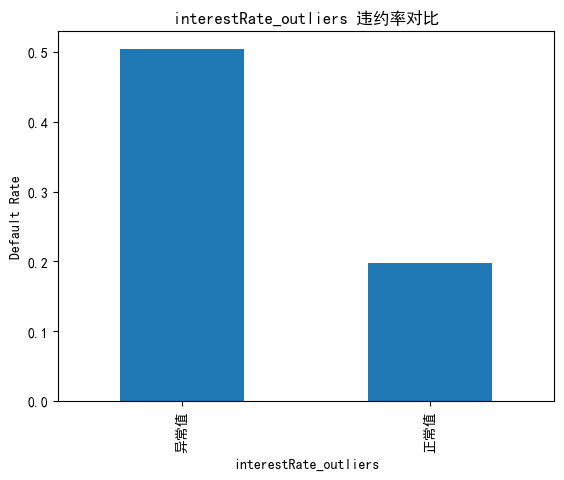

In [80]:
import matplotlib.pyplot as plt

fea = 'interestRate_outliers'

rate = data_train.groupby(fea)['isDefault'].mean()

rate.plot(kind='bar')
plt.title(f'{fea} 违约率对比')
plt.ylabel('Default Rate')
plt.show()

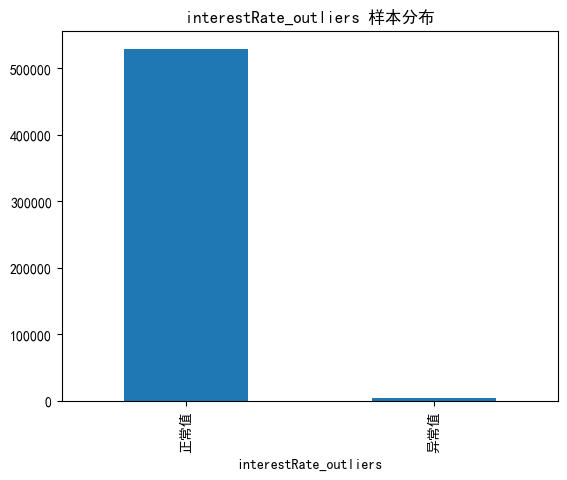

In [81]:
data_train[fea].value_counts().plot(kind='bar')
plt.title(f'{fea} 样本分布')
plt.show()

In [172]:
for fea in numerical_fea:
    data_train = data_train[data_train[fea+'_outliers']=='正常值']
    data_train = data_train.reset_index(drop=True) 

In [173]:
data['loanAmnt_bin1'] = np.floor_divide(data['loanAmnt'], 1000)

In [174]:
data['loanAmnt_bin2'] = np.floor(np.log10(data['loanAmnt']))
n

In [175]:
data['loanAmnt_bin3'] = pd.qcut(data['loanAmnt'], 10, labels=False)

In [180]:
data[['loanAmnt', 'loanAmnt_bin3']].head(10)

,loanAmnt,loanAmnt_bin3
0,14000.0,5
1,20000.0,7
2,12000.0,4
3,17500.0,6
4,35000.0,9
5,16000.0,6
6,25000.0,8
7,4500.0,0
8,12000.0,4
9,16500.0,6


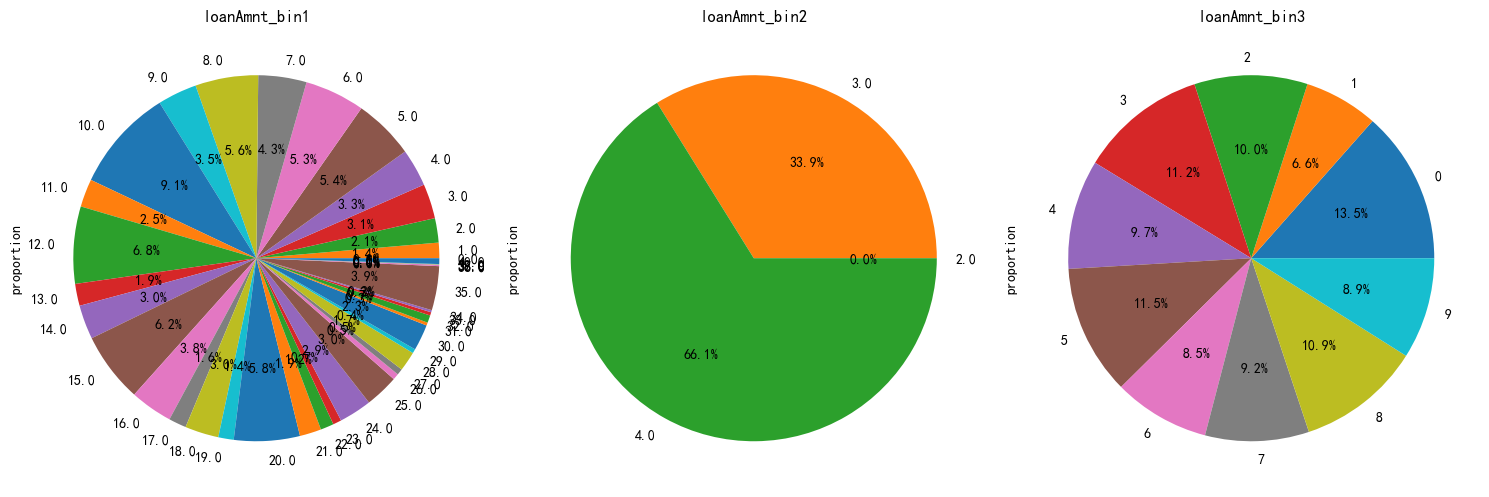

In [182]:
import matplotlib.pyplot as plt

cols = ['loanAmnt_bin1', 'loanAmnt_bin2', 'loanAmnt_bin3']

plt.figure(figsize=(15, 5))

for i, col in enumerate(cols):
    plt.subplot(1, 3, i+1)
    
    data[col].value_counts(normalize=True).sort_index().plot(
        kind='pie',
        autopct='%1.1f%%'
    )
    
    plt.title(col)

plt.tight_layout()
plt.show()

In [191]:
print(data_train.columns)

Index(['id', 'loanAmnt', 'term', 'interestRate', 'installment', 'grade',
       'subGrade', 'employmentTitle', 'employmentLength', 'homeOwnership',
       'annualIncome', 'verificationStatus', 'issueDate', 'isDefault',
       'purpose', 'postCode', 'regionCode', 'dti', 'delinquency_2years',
       'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec',
       'pubRecBankruptcies', 'revolBal', 'revolUtil', 'totalAcc',
       'initialListStatus', 'applicationType', 'earliesCreditLine', 'title',
       'policyCode', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8',
       'n9', 'n10', 'n11', 'n12', 'n13', 'n14', 'issueDateDT', 'id_outliers',
       'loanAmnt_outliers', 'term_outliers', 'interestRate_outliers',
       'installment_outliers', 'employmentTitle_outliers',
       'homeOwnership_outliers', 'annualIncome_outliers',
       'verificationStatus_outliers', 'issueDate_outliers', 'purpose_outliers',
       'postCode_outliers', 'regionCode_outliers', 'dti_outliers',
       'delinquen

In [187]:
for col in ['grade', 'subGrade']: 
    temp_dict = data_train.groupby([col])['isDefault'].agg(['mean']).reset_index().rename(columns={'mean': col + '_target_mean'})
    temp_dict.index = temp_dict[col].values
    temp_dict = temp_dict[col + '_target_mean'].to_dict()

    data_train[col + '_target_mean'] = data_train[col].map(temp_dict)
    data_test[col + '_target_mean'] = data_test[col].map(temp_dict)

In [193]:
for df in [data_train, data_test]:
    for item in ['n0','n1','n2','n2','n4','n5','n6','n7','n8','n9','n10','n11','n12','n13','n14']:
        df['grade_to_mean_' + item] = df['grade'] / df.groupby([item])['grade'].transform('mean')
        df['grade_to_std_' + item] = df['grade'] / df.groupby([item])['grade'].transform('std')


In [197]:
#label-encode:subGrade,postCode,title
# 高维类别特征需要进行转换
for col in tqdm(['employmentTitle', 'postCode', 'title','subGrade']):
    le = LabelEncoder()
    le.fit(list(data_train[col].astype(str).values) + list(data_test[col].astype(str).values))
    data_train[col] = le.transform(list(data_train[col].astype(str).values))
    data_test[col] = le.transform(list(data_test[col].astype(str).values))
print('Label Encoding 完成')

100%|██████████| 4/4 [00:07<00:00,  1.84s/it]

Label Encoding 完成


                features      corr
46  subGrade_target_mean  0.265604
5               subGrade  0.264371
53      grade_to_mean_n4  0.259370
45     grade_target_mean  0.259307
65     grade_to_mean_n10  0.258725
..                   ...       ...
16          ficoRangeLow -0.127717
25       applicationType       NaN
28            policyCode       NaN
40                   n11       NaN
41                   n12       NaN

[75 rows x 2 columns]


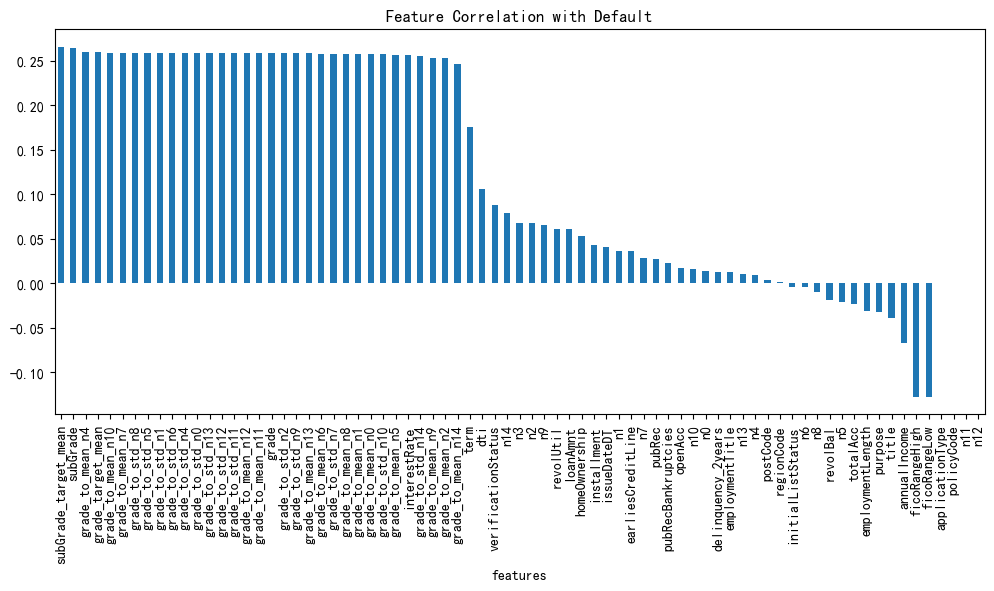

In [215]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 删除无用字段
# =========================
for data in [data_train, data_test]:
    data.drop(['issueDate', 'id'], axis=1, inplace=True, errors='ignore')

# =========================
# 2. 缺失值处理
# =========================
data_train = data_train.fillna(-1)
data_test = data_test.fillna(-1)

# =========================
# 3. 去掉 outliers 标记列（关键🔥）
# =========================
outlier_cols = [col for col in data_train.columns if 'outliers' in col]
data_train = data_train.drop(outlier_cols, axis=1, errors='ignore')
data_test = data_test.drop(outlier_cols, axis=1, errors='ignore')

# =========================
# 4. 构造训练集
# =========================
x_train = data_train.drop(['isDefault'], axis=1)
y_train = data_train['isDefault']

# =========================
# 5. 只保留数值特征（防止字符串报错）
# =========================
x_train = x_train.select_dtypes(include=[np.number])

# =========================
# 6. 计算相关性
# =========================
data_corr = x_train.corrwith(y_train)

# =========================
# 7. 整理结果
# =========================
result = pd.DataFrame({
    'features': data_corr.index,
    'corr': data_corr.values
})

result = result.sort_values(by='corr', ascending=False)

print(result)

# =========================
# 8. 可视化
# =========================
plt.figure(figsize=(12,5))
result.set_index('features')['corr'].plot(kind='bar')
plt.title('Feature Correlation with Default')
plt.show()

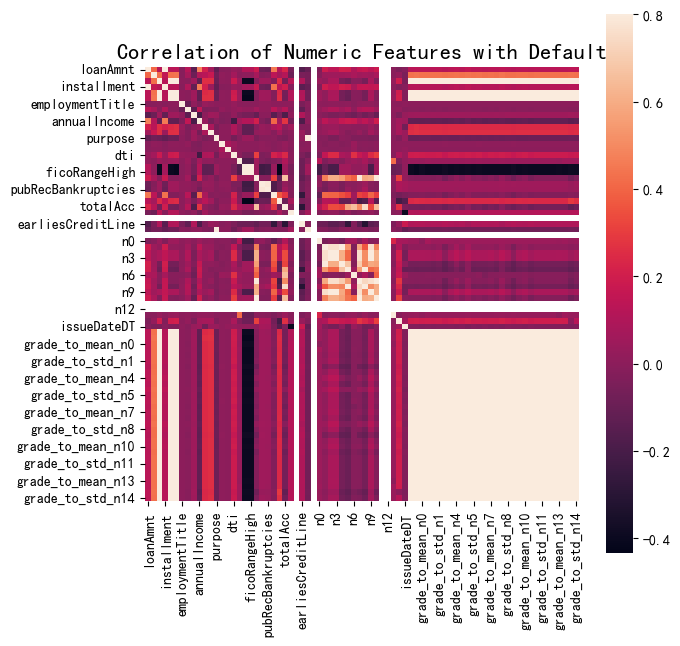

In [219]:
data_numeric = data_train.select_dtypes(include=[np.number])
correlation = data_numeric.corr()

plt.figure(figsize=(7,7))
plt.title('Correlation of Numeric Features with Default', size=16)
sns.heatmap(correlation, square=True, vmax=0.8)
plt.show()

In [223]:
features = [f for f in data_train.columns if f not in ['id','issueDate','isDefault'] and '_outliers' not in f]
x_train = data_train[features]
x_test = data_test[features]
y_train = data_train['isDefault']

In [231]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

def cv_model(clf, train_x, train_y, test_x, clf_name):
    folds = 5
    seed = 2020
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    train_pred = np.zeros(train_x.shape[0])
    test_pred = np.zeros(test_x.shape[0])

    cv_scores = []

    for i, (train_index, valid_index) in enumerate(kf.split(train_x, train_y)):
        print('*************** Fold {} ***************'.format(i+1))

        trn_x = train_x.iloc[train_index]
        trn_y = train_y.iloc[train_index]
        val_x = train_x.iloc[valid_index]
        val_y = train_y.iloc[valid_index]

        # ===================== LGB =====================
        if clf_name == "lgb":
            train_matrix = clf.Dataset(trn_x, label=trn_y)
            valid_matrix = clf.Dataset(val_x, label=val_y)

            params = {
                'boosting_type': 'gbdt',
                'objective': 'binary',
                'metric': 'auc',
                'num_leaves': 31,
                'learning_rate': 0.05,
                'feature_fraction': 0.8,
                'bagging_fraction': 0.8,
                'bagging_freq': 4,
                'seed': 2020,
                'verbose': -1
            }

            model = clf.train(
                params,
                train_matrix,
                num_boost_round=5000,
                valid_sets=[train_matrix, valid_matrix],
                callbacks=[
                    clf.log_evaluation(period=200),
                    clf.early_stopping(200)
                ]
            )

            val_pred = model.predict(val_x, num_iteration=model.best_iteration)
            test_fold_pred = model.predict(test_x, num_iteration=model.best_iteration)

        # ===================== XGB =====================
        elif clf_name == "xgb":
            train_matrix = clf.DMatrix(trn_x, label=trn_y)
            valid_matrix = clf.DMatrix(val_x, label=val_y)
            test_matrix = clf.DMatrix(test_x)

            params = {
                'booster': 'gbtree',
                'objective': 'binary:logistic',
                'eval_metric': 'auc',
                'max_depth': 5,
                'subsample': 0.8,
                'colsample_bytree': 0.8,
                'eta': 0.05,
                'seed': 2020,
                'nthread': 4
            }

            watchlist = [(train_matrix, 'train'), (valid_matrix, 'eval')]

            model = clf.train(
                params,
                train_matrix,
                num_boost_round=5000,
                evals=watchlist,
                verbose_eval=200,
                early_stopping_rounds=200
            )

            val_pred = model.predict(valid_matrix)
            test_fold_pred = model.predict(test_matrix)

        # ===================== CAT =====================
        elif clf_name == "cat":
            params = {
                'learning_rate': 0.05,
                'depth': 6,
                'l2_leaf_reg': 10,
                'loss_function': 'Logloss',
                'eval_metric': 'AUC',
                'random_seed': 2020,
                'verbose': 200
            }

            model = clf.CatBoostClassifier(**params)

            model.fit(
                trn_x, trn_y,
                eval_set=(val_x, val_y),
                use_best_model=True,
                verbose=200
            )

            val_pred = model.predict_proba(val_x)[:, 1]
            test_fold_pred = model.predict_proba(test_x)[:, 1]

        # ===================== 结果融合 =====================
        train_pred[valid_index] = val_pred
        test_pred += test_fold_pred / folds

        score = roc_auc_score(val_y, val_pred)
        cv_scores.append(score)

        print("Fold AUC:", score)
        print("Current CV mean:", np.mean(cv_scores))
        print("*" * 50)

    print(f"{clf_name} AUC mean: {np.mean(cv_scores)}")
    print(f"{clf_name} AUC std: {np.std(cv_scores)}")

    return train_pred, test_pred

In [233]:
def lgb_model(x_train, y_train, x_test):
    lgb_train, lgb_test = cv_model(lgb, x_train, y_train, x_test, "lgb")
    return lgb_train, lgb_test

def xgb_model(x_train, y_train, x_test):
    xgb_train, xgb_test = cv_model(xgb, x_train, y_train, x_test, "xgb")
    return xgb_train, xgb_test

def cat_model(x_train, y_train, x_test):
    cat_train, cat_test = cv_model(CatBoostRegressor, x_train, y_train, x_test, "cat")

In [235]:
lgb_train, lgb_test = lgb_model(x_train, y_train, x_test)

*************** Fold 1 ***************
Training until validation scores don't improve for 200 rounds
[200]	training's auc: 0.745035	valid_1's auc: 0.730079
[400]	training's auc: 0.761888	valid_1's auc: 0.731537
[600]	training's auc: 0.776073	valid_1's auc: 0.731927
[800]	training's auc: 0.789456	valid_1's auc: 0.731927
[1000]	training's auc: 0.802125	valid_1's auc: 0.731844
Early stopping, best iteration is:
[856]	training's auc: 0.793086	valid_1's auc: 0.732061
Fold AUC: 0.7320610559081313
Current CV mean: 0.7320610559081313
**************************************************
*************** Fold 2 ***************
Training until validation scores don't improve for 200 rounds
[200]	training's auc: 0.744671	valid_1's auc: 0.730944
[400]	training's auc: 0.761616	valid_1's auc: 0.732287
[600]	training's auc: 0.7762	valid_1's auc: 0.732286
Early stopping, best iteration is:
[405]	training's auc: 0.761992	valid_1's auc: 0.732348
Fold AUC: 0.7323484981236138
Current CV mean: 0.732204777015872

建立模型

In [247]:
def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() 
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() 
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    return df